In [1]:
# Capstone -- function 6 (5D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay, ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 6

5D, 23 observations (20 initial + weeks 2–4), all of them in the fit. Search domain is the unit cube `[0,1]^5`.

I propose with `ucb`, `KAPPA = 0.25`: **`[0.518201, 0.321942, 0.527558, 0.786655, 0.000000]`** (GP mean −0.3832, std 0.0343, so a predicted gain of **+0.0029** on an incumbent of −0.386121).

## Week 4 worked, and the floor contact was right

`[0.497078, 0.264731, 0.582415, 0.764018, 0.0]` came back at **−0.386121**, a new best. My progress so far: initial −0.7143 → wk2 −0.5120 → wk3 −0.5120 (no gain — that point went out of domain) → wk4 **−0.3861**.

Its `x4 = 0.0` sat on the lower bound, which I had recorded as merely "legitimate". It is better than that: **x4 is monotone decreasing, so 0 is its optimal end.** Spearman(x4, y) = −0.654, the low-x4 half of my data has mean `y` −1.148 against −1.616 for the high half, and the five highest-x4 observations run −1.67 to −2.57. Every acquisition I tried — `exploit`, `ucb` at 0, 0.25 and 0.5, EI and PI at small `xi` — independently puts x4 at 0. So the floor contact is the model agreeing with the data, not an artefact.

## Nothing is held: all five axes are live

I hold no axis fixed here. My flat-axis rule is **GP mean-variation below 5% of the largest, or a length-scale pinned at the `length_scale_bounds` ceiling** — and neither fires on any axis:

| axis | mean-variation | length-scale | Spearman | reading |
|---|---|---|---|---|
| x0 | 1.132 | 0.595 | −0.030 | non-monotone |
| x1 | 0.666 | 1.024 | −0.290 | non-monotone |
| x2 | 0.294 | 1.253 | +0.183 | weak |
| x3 | 0.825 | 1.062 | +0.602 | monotone |
| x4 | 0.958 | 1.225 | −0.654 | monotone |

The length-scale column alone would mislead me here. Four of these exceed the domain width of 1.0, which reads as "flat" — but a long length-scale means *no short-range structure*, not *no effect*. x4's is 1.225 and it still moves the posterior mean by 0.958, nearly as much as x0 does. Mean-variation is what separates the two cases.

## Why `KAPPA = 0.25`

**The largest `kappa` whose predicted mean still beats the incumbent.**

| kappa | proposal | pred. mean | gain vs incumbent | step |
|---|---|---|---|---|
| 0 (= `exploit`) | `[0.5129, 0.3003, 0.5507, 0.7758, 0.0]` | −0.38185 | **+0.00427** | 0.052 |
| **0.25** | `[0.5182, 0.3219, 0.5276, 0.7867, 0.0]` | −0.38325 | **+0.00287** | 0.085 |
| 0.5 (my previous choice) | `[0.5115, 0.3283, 0.4641, 0.8025, 0.0]` | −0.38952 | **−0.00340** | 0.141 |

My previous committed `0.5` was predicting a *loss*. `0.25` buys a 65% larger step than pure `exploit` for a third less predicted gain, and it keeps a variance term rather than dropping to none at all.

A mode switch sits between `kappa` 1 and 2 — x2 jumps 0.33 → 1.0 while x1 drops 0.318 → 0 — so anything above 1 is a different question, not a more exploratory version of this one.

The backtest agrees only weakly, which is what I expect of it: `exploit` leads (0.4025) with `ucb_k0.25` (+0.031 ± 0.034), `ucb_k0.5` (+0.043 ± 0.048) and `ucb_k1` (+0.094 ± 0.053) all within noise. The predicted-gain table is my reason; this is not.

## EI and PI: `xi` is live here, and they still lose

`xi` genuinely moves the proposal on this function. EI's predicted mean walks −0.616 → −0.635 → −1.706 as `xi` rises from 0.1% to 100% of the `y` spread, the point itself moving 0.042 then 1.018. But both families head for regions the model rates far below the incumbent, so they are variance-seekers here rather than degenerate. The backtest puts PI 2.5 s.e. and EI 4.4 s.e. behind. Only PI at `xi` ≈ 0.1% of spread comes close, and there it is just `exploit` with extra steps.

## What I am watching

- **Local search is nearly finished.** The best predicted gain available anywhere is +0.0043, from pure `exploit`, and every candidate that improves at all improves by under 0.005. The largest gap on my most informative axis (x0) is 0.137 against a length-scale of 0.595 — a ratio of **0.23**, well under the 1.0 that would say structure is still unresolved.
- **But I have explored almost nothing.** The convex hull is **6.4%** of the cube and 22 of 23 points are hull vertices, so the hull test is near-vacuous at D=5. Posterior std at the incumbent is 0.0007 against a domain median of 0.210. Real exploration goes to corners: `max_variance` proposes `[0,0,0,0,0]` at a predicted −1.647.
- So if this week fails to beat −0.386121, that is my signal to spend a deliberate exploration budget rather than keep polishing. I should not read a small miss as "lower `kappa` further".
- **The out-of-domain week-3 point stays in the fit.** Its `x3 = 1.5454` is the only coordinate outside the cube, its `y` (−1.2148) is unremarkable, and the search is clamped to `[0,1]` regardless, so nothing can go back out there.
- **Every length-scale contracted by 31–50% over the three collected points**, which trips my own 50% warning at x3. A contraction means the GP is finding *more* structure rather than being distorted, so it is less alarming than inflation would be — but the variance surface has not settled, so I treat variance-driven reasoning carefully this week.
- LOO: R² **+0.590**, **83.4%** of point pairs ordered correctly, 19/23 inside their own 95% interval. The worst-predicted point is week 3, the out-of-domain one.

In [2]:
X_initial = np.load("initial_data/function_6/initial_inputs.npy")
y_initial = np.load("initial_data/function_6/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 5, f"Expected a 5D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week.

In [3]:
# My collected observations, from weekly_data/function_6/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2
#   - week 3 -- x3 went out of domain (1.5454), x4 at the floor
#   - week 4 -- x4 at the floor again; this one is my new best

new_X, new_y, pending_X = load_collected(6, D)

print("observations collected so far:", len(new_y))
print("latest y: %.6f | best before it: %.6f (change %+.6f)"
      % (new_y[-1], max(y_initial.max(), new_y[0]),
         new_y[-1] - max(y_initial.max(), new_y[0])))
print("-> %s" % ("the WORST observation on record"
                 if new_y[-1] < min(y_initial.min(), new_y[0])
                 else "within the existing range"))


weekly store: 3 resulted observation(s), 1 pending proposal [0.518201 0.321942 0.527558 0.786655 0.      ]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 3
latest y: -0.386121 | best before it: -0.511982 (change +0.125862)
-> within the existing range


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.6f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# The domain is the unit cube, so bounds are [0,1] on every axis. BOTH edges
# are real domain constraints now -- the upper one used to be pad_fraction
# padding, and the checks below no longer treat the two differently.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# One earlier proposal went above 1 before I knew the domain, so it sits outside
# these bounds. I validate the in-domain subset -- catching bounds too narrow for
# the data is what validate_bounds_consistency is for -- and report the rest
# rather than dying on it.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)

if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) lie OUTSIDE the [0,1] domain,"
          " proposed before it was known:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  It stays IN the fit: its y is unremarkable, and it SHORTENS length-scales")
    print("  rather than inflating them, so it costs me no resolution where I am")
    print("  searching. The search is clamped to [0,1] regardless, so nothing can be")
    print("  proposed out there again.")
print("\nBounds:\n", np.round(bounds, 4))

print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" y={new_y[r]:.6f}")

# The convex hull is a weak notion at D=5 with this few points. Quantify how
# weak, so I read the check below with the right expectations.
try:
    hull = Delaunay(X)
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.1%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices"
          " -- at D=5 nearly all of them are, so the hull test is weak here")
except Exception as exc:
    hull = None
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (20, 5) | combined X shape: (23, 5)
y range: -2.571170 to -0.386121 (spread 2.185049, std 0.513446)

1 observation(s) lie OUTSIDE the [0,1] domain, proposed before it was known:
  x3=1.5454   y=-1.2148
  It stays IN the fit: its y is unremarkable, and it SHORTENS length-scales
  rather than inflating them, so it costs me no resolution where I am
  searching. The search is clamped to [0,1] regardless, so nothing can be
  proposed out there again.

Bounds:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]

collected points vs the INITIAL batch's range:
  week 2  x0=0.519691  initial range [0.0217, 0.9577]  outside=False
  week 2  x1=0.384667  initial range [0.1144, 0.9319]  outside=False
  week 2  x2=0.382026  initial range [0.0165, 0.9788]  outside=False
  week 2  x3=0.764661  initial range [0.0456, 0.9617]  outside=False
  week 2  x4=0.218558  initial range [0.0049, 0.8928]  outside=False
  -> week 2: 0 of 5 coordinates outside, y=-0.511982
  week 3  x0=0.371752  initial 

## Is the model stable and calibrated?

Two checks, both cheap.

First, refit on the initial batch alone and predict each collected point. That fit never saw them, so the miss in units of its own predicted sigma tells me how far to trust the model's uncertainty. All three land inside 2.1 sigma.

Second, compare kernels before and after. One observation reshaping the model would be a reason to distrust any variance-driven acquisition. Here every length-scale *contracted*, by 31–50%, which trips my own 50% threshold at x3. Contraction means the GP is finding more structure rather than being distorted by an outlier, so it is the benign direction — but it does say the variance surface has not settled yet.

In [5]:
# Both fits first, in one block, so no ConvergenceWarning can land between the
# rows printed below.
with fitting("before/after fits for the collected observations"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is genuinely out of
# sample. The model that actually proposed week 3 also had week 2, so for the
# later rows this understates what was known at proposal time.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.6f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))
print("ratio (after/before):", np.round(ls_after / ls_before, 2))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

# Direction matters as much as size here: a CONTRACTION means the GP is finding
# more structure, which is the benign case. Inflation is the one that suppresses
# sigma where the search needs resolution.
_move = float(np.max(np.abs(ls_after / ls_before - 1)))
if _move > 0.5:
    _dirn = ("contracted" if np.mean(ls_after / ls_before) < 1.0 else "INFLATED")
    print(f"\n*** A length-scale moved by {_move:.0%} across the collected"
          f" observations; they {_dirn}.")
    if _dirn == "contracted":
        print("    Contraction is the benign direction -- more structure, not less --")
        print("    but the variance surface has not settled, so treat variance-driven")
        print("    acquisitions with care this week. ***")
    else:
        print("    Inflation over-smooths the posterior and suppresses sigma where the")
        print("    search needs resolution. Distrust variance-driven acquisitions. ***")


[fitting: before/after fits for the collected observations] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted -0.596318 +/- 0.149674   actual -0.511982
    miss +0.084336 = +0.6 sigma  -> well calibrated
  week 3: predicted -0.208368 +/- 0.468186   actual -1.214796
    miss -1.006428 = -2.1 sigma  -> well calibrated
  week 4: predicted -0.346795 +/- 0.207883   actual -0.386121
    miss -0.039326 = -0.2 sigma  -> well calibrated

kernel before: 2.46**2 * Matern(length_scale=[0.864, 1.64, 2.06, 2.13, 2.17], nu=2.5) + WhiteKernel(noise_level=0.0462)
kernel after : 1.41**2 * Matern(length_scale=[0.595, 1.02, 1.25, 1.06, 1.23], nu=2.5) + WhiteKernel(noise_level=1e-06)

length-scales before: [0.864 1.638 2.065 2.133 2.173]
length-scales after : [0.595 1.024 1.253 1.062 1.225]
ratio (after/before): [0.69 0.63 0.61 0.5  0.56]

pinned (GP treats as irre

## Which axes matter, and in what way

Two measures, because they answer different questions.

**GP mean-variation** — sweep one axis with the others held at the incumbent — asks how much the model thinks that axis moves the response, in any pattern at all. **Spearman rank correlation** asks whether there is a usable monotone direction. An axis can score high on the first and near-zero on the second, and x0 is exactly that: mean-variation 1.132, the shortest length-scale of the five, rank correlation −0.030. Not a contradiction — Spearman is blind to non-monotone structure by construction.

The cell then applies my flat-axis rule: an axis is flat if its mean-variation is under 5% of the largest, **or** its length-scale is pinned near the 10.0 ceiling. A flat axis would get held at the incumbent, because a flat acquisition surface makes its coordinate an optimiser artefact rather than a prediction. Nothing qualifies here, so all five axes are searched and this notebook has no restricted-search cell.

It also prints which axes are monotone and which end is their best, so that a proposal sitting on a domain bound can be read as expected rather than as the optimiser stopping arbitrarily.

In [6]:
incumbent = X[np.argmax(y)]

# Every sweep first, then print. The "reading" column compares each axis against
# the LARGEST mean-variation, so computing and printing in one pass made it
# compare against a running maximum and depend on axis order.
spans = np.zeros(D)       # mean-variation over the full domain
spans_obs = np.zeros(D)   # mean-variation over the observed range only
srho = np.zeros(D)        # Spearman rank correlation with y
for d in range(D):
    for col, (lo, hi) in enumerate([(bounds[d, 0], bounds[d, 1]),
                                    (X[:, d].min(), X[:, d].max())]):
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        (spans if col == 0 else spans_obs)[d] = m.max() - m.min()
    srho[d] = spearmanr(X[:, d], y)[0]

print("incumbent (best observed):", np.round(incumbent, 6), " y = %.6f" % y.max())
print("\n%3s | %17s | %15s | %8s | %9s | %s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman", "reading"))
for d in range(D):
    reading = ("monotone direction" if abs(srho[d]) > 0.4
               else "non-monotone" if spans[d] > 0.5 * spans.max() else "weak")
    print("%3d | %17.4g | %15.4g | %8.3f | %+9.3f | %s"
          % (d, spans[d], spans_obs[d], ls_after[d], srho[d], reading))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
print("axes searched:", live)
print("dominance: x%d moves the mean %.1fx more than the next-largest (x%d)"
      % (int(np.argmax(spans)), spans[np.argsort(spans)[-1]] / spans[np.argsort(spans)[-2]],
         int(np.argsort(spans)[-2])))
# A monotone axis whose best end is a domain bound will put the proposal ON that
# bound. That is the model agreeing with the data, not the failure mode the
# proposal cell warns about, so I flag it here to keep the two apart.
for d in range(D):
    if abs(srho[d]) > 0.4:
        end = bounds[d, 0] if srho[d] < 0 else bounds[d, 1]
        which = "LOWER" if srho[d] < 0 else "UPPER"
        print(f"  x{d} is monotone (spearman {srho[d]:+.3f}): its best end is the"
              f" {which} bound ({end:.1f}), so a proposal sitting there is expected")

if not flat:
    print("-> nothing to hold fixed: all axes are live, so my search is unrestricted")

incumbent (best observed): [0.497078 0.264731 0.582415 0.764018 0.      ]  y = -0.386121

 ax | GP mean-variation |  same, observed | len-scale |  spearman | reading
  0 |             1.132 |           1.011 |    0.595 |    -0.030 | non-monotone
  1 |            0.6661 |          0.5781 |    1.024 |    -0.290 | non-monotone
  2 |            0.2945 |          0.2787 |    1.253 |    +0.183 | weak
  3 |             0.825 |          0.7613 |    1.062 |    +0.602 | monotone direction
  4 |            0.9581 |          0.8336 |    1.225 |    -0.654 | monotone direction

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): none
axes searched: [0, 1, 2, 3, 4]
dominance: x0 moves the mean 1.2x more than the next-largest (x4)
  x3 is monotone (spearman +0.602): its best end is the UPPER bound (1.0), so a proposal sitting there is expected
  x4 is monotone (spearman -0.654): its best end is the LOWER bound (0.0), so a proposal sitting there is expected
-> nothing to hold fixed: all axe

## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a seed set, which fits the GP, and a held-out candidate set whose true `y` is known but hidden from the fit, then sees which config would have picked the best candidate. No real evaluations spent. I size `xi` as 1% of the `y` spread rather than leaving it at the default 0.01, which would be a rounding error here.

**It is biased toward exploitation by construction** — it scores recognition of points whose `y` is already known, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. A low-`kappa` config at the top is therefore close to tautological. I use it as one weak input, never as the decider.

Two things the cell does before trusting it. It checks whether `xi` is a live dial at all rather than assuming so, and it reports every config *paired* against the leader over the same splits — the per-split difference and its standard error say whether a gap is real, which two means side by side do not.

xi for the PI/EI rows: 0.021850 (1% of the y spread)

is xi a live dial? (proposal movement as xi grows)


[fitting: ei at xi=0.1% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=  0.1% of spread: pred mean -0.6161


[fitting: ei at xi=5.0% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=  5.0% of spread: pred mean -0.6353  moved 0.0423
[fitting: ei at xi=100.0% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  ei xi=100.0% of spread: pred mean -1.7056  moved 1.0177


[fitting: pi at xi=0.1% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  pi xi=  0.1% of spread: pred mean -0.3822


[fitting: pi at xi=5.0% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  pi xi=  5.0% of spread: pred mean -0.5475  moved 0.4537
[fitting: pi at xi=100.0% of spread] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
  pi xi=100.0% of spread: pred mean -1.7056  moved 1.0523
  -> xi IS live here, but both families head for predicted
     means far below the incumbent, so they are variance-seeking here.



[fitting: acquisition backtest, 50 splits] 119 warnings held back, 6 distinct:
    44 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    23 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    21 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
    15 x  ConvergenceWarning  k1__k2__length_scale (dim 2) pinned at upper bound 10.0
    10 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
     6 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |       0.4025 |         0.3035 |        -0.9314
   ucb_k0.25 |       0.4339 |         0.4047 |        -0.9628
    ucb_k0.5 |       0.4457 |         0.4047 |        -0.9746
      ucb_k1 |       0.4967 |         0.5005 |         -1.026
          pi |       0.5587 |        

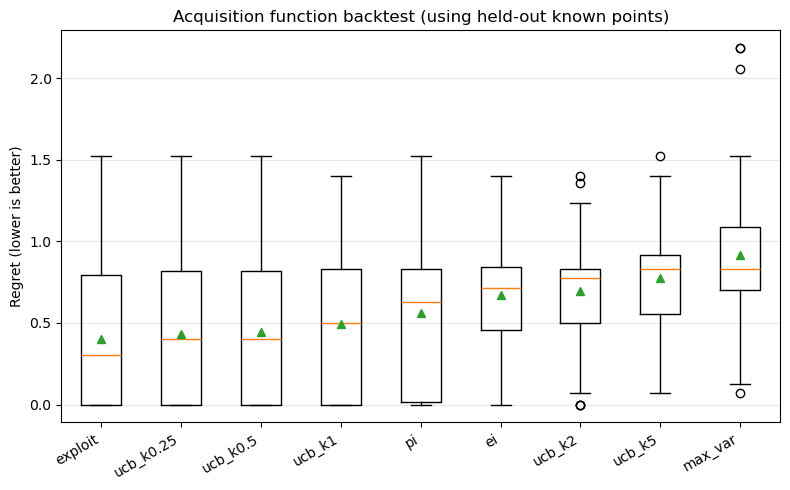

In [7]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.25", "acquisition": "ucb", "kappa": 0.25},
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)")

# Is xi a live dial here, or degenerate? Checked rather than assumed. Here it
# genuinely moves the proposal -- but toward regions the model rates badly.
print("\nis xi a live dial? (proposal movement as xi grows)")
_prev = {}
for _acq in ("ei", "pi"):
    for _frac in (0.001, 0.05, 1.0):
        _xi = _frac * (y.max() - y.min())
        with fitting(f"{_acq} at xi={_frac:.1%} of spread"):
            _p, _ = generate_next_point(X, y, bounds, acquisition=_acq, xi=_xi,
                                        maximize=True, n_restarts=40, random_state=0)
        _m, _ = gp_check.predict(normalize(_p.reshape(1, -1), bounds), return_std=True)
        _mv = "" if _acq not in _prev else f"  moved {np.linalg.norm(_p - _prev[_acq]):.4f}"
        print(f"  {_acq} xi={_frac:>6.1%} of spread: pred mean {_m[0]:+.4f}{_mv}")
        _prev[_acq] = _p
print("  -> xi IS live here, but both families head for predicted")
print("     means far below the incumbent, so they are variance-seeking here.\n")

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared PAIRED on the same
# splits, so "within noise" below means |mean difference| <= 2 standard errors --
# plain arithmetic, no statistical test. Read it knowing the metric scores
# RECOGNITION of points whose y is already known, which is an exploitation task.
CHOSEN = "ucb_k0.25"        # must name the committed KAPPA; asserted where KAPPA is set

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {k: float(backtest_results[k]["regret"].mean()) for k in names}
med_r = {k: float(np.median(backtest_results[k]["regret"])) for k in names}
ranked = sorted(names, key=lambda k: mean_r[k])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [k for k in ranked[1:]
        if abs(paired_gap(leader, k)[0]) <= 2 * paired_gap(leader, k)[1]]
worse = [k for k in ranked[1:] if k not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda k: med_r[k])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for k in ranked[1:]:
    gap, se = paired_gap(leader, k)
    print(f"  {k:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>5.1f} s.e.)"
          f"   {'within noise' if k in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")
print("Do NOT switch on this table alone -- see the bias note above, and check")
print("where each candidate would actually propose before acting on it.")

plot_acquisition_backtest(backtest_results)
plt.show()


## Comparing kappa before I commit

One shared GP fit, then a look at where each candidate `kappa` would send me right now. Because the model is shared, any difference between rows is `kappa` alone rather than refit noise.

**My criterion is the largest `kappa` whose predicted mean still beats the incumbent.** I used to use "the largest `kappa` whose proposal touches no upper bound", which rested on upper-bound contact meaning `pad_fraction` had chosen the coordinate rather than the model. Bounds are the true domain now, so upper contact would mean the constrained optimum genuinely sits on the boundary — the old criterion had nothing left to stand on. The replacement is checkable and gets printed below.

Three things I read off it:

1. **Does the predicted mean still beat the incumbent?** At `kappa = 0.5` it does not, which is why my previously committed value had to go.
2. **Is there a mode switch?** Between `kappa` 1 and 2 the proposal jumps — x2 from 0.33 out to the domain maximum, x1 down to its floor — so anything above 1 is a different question rather than a more exploratory version of this one.
3. **Which bound is each coordinate on, and is that axis monotone toward it?** x4 sits at 0.0 at every `kappa`, and it is monotone decreasing, so that is the model agreeing with the data rather than the optimiser giving up.

[fitting: kappa sweep (one shared GP)] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 | [0.513,0.3  ,0.551,0.776,0.   ] |    -0.3818 |    -0.3818 |    0.0227 |          0.0516
    0.25 | [0.518,0.322,0.528,0.787,0.   ] |    -0.3747 |    -0.3832 |    0.0343 |          0.0851
     0.5 | [0.511,0.328,0.464,0.802,0.   ] |    -0.3645 |    -0.3895 |    0.0501 |          0.1405
       1 | [0.474,0.318,0.33 ,0.837,0.   ] |    -0.3253 |    -0.4350 |    0.1097 |          0.2688
       2 | [0.423,0.   ,1.   ,0.591,0.   ] |    -0.1111 |    -0.6483 |    0.2686 |          0.5291
       5 |         [0.,0.,0.,1.,0.] |     1.2017 |    -1.2586 |    0.4921 |          0.8438

 kappa | on UPPER domain edge | on lower domain edge | in hull
     0 |               

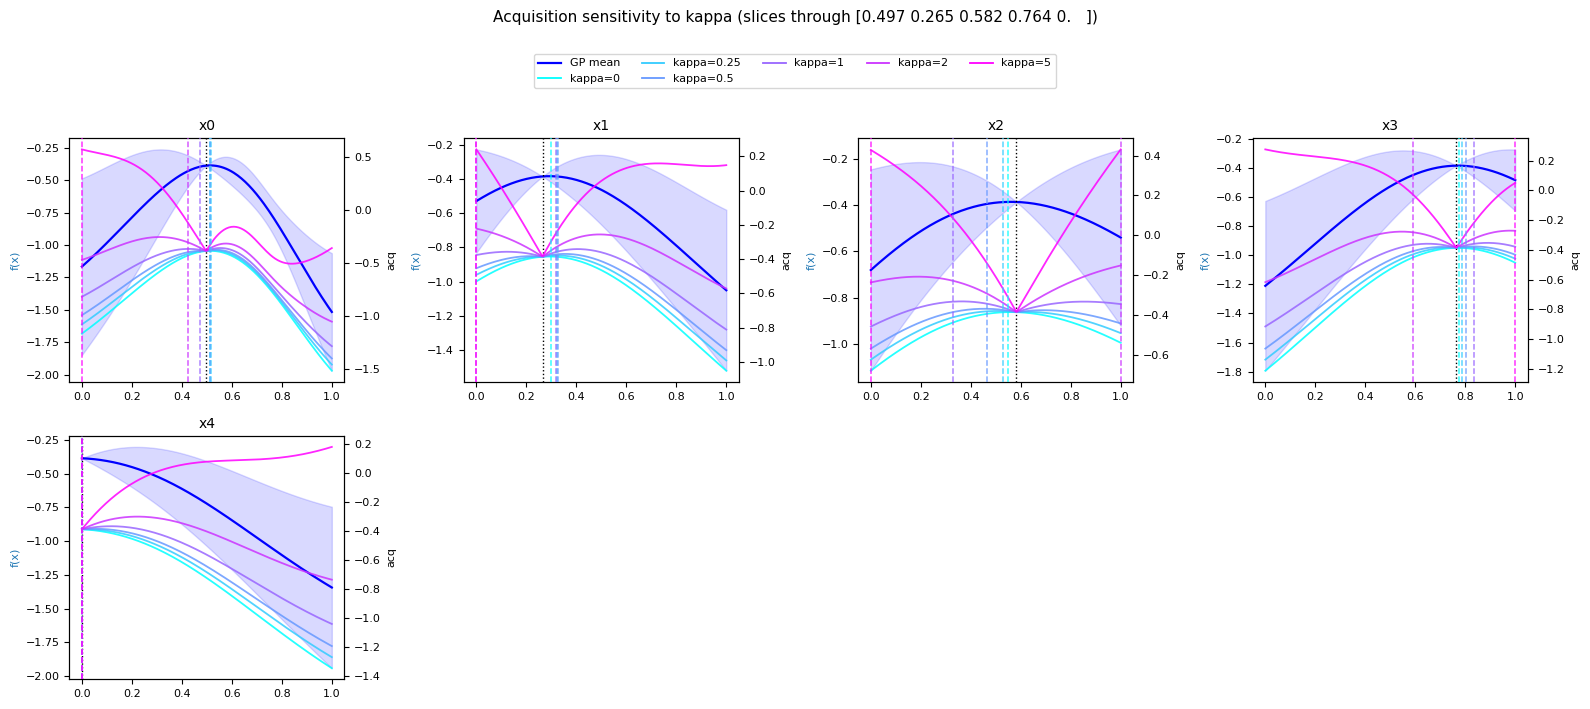


using kappa = 0.25 (dimensionless -- no y-scaling needed)


[fitting: predicted-gain check across kappa] 4 warnings held back:
     4 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
chosen as the largest kappa whose predicted mean still beats the incumbent:
  kappa=0.0   pred mean -0.381846  gain +0.004275  step 0.0516
  kappa=0.25  pred mean -0.383248  gain +0.002873  step 0.0851  <- committed
  kappa=0.5   pred mean -0.389517  gain -0.003397  step 0.1405
  kappa=1.0   pred mean -0.434976  gain -0.048855  step 0.2688
  (a mode switch sits between kappa 1.0 and 1.5, so >1 is off the table)


In [8]:
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.0, 0.25, 0.5, 1.0, 2.0, 5.0],
                                          maximize=True, n_restarts=40, random_state=0)

print_kappa_comparison(kappa_rows)


def bound_report(p):
    """Report which coordinates sit on a domain edge, upper and lower separately.

    Bounds are the true domain [0,1], so NEITHER edge is automatically a defect
    -- contact means the constrained optimum is on the boundary, which on a
    monotone axis is exactly right. I judge it per axis against that axis's
    monotone direction (see the axis cell), not by which edge it is.
    """
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print(f"\n{'kappa':>6} | {'on UPPER domain edge':>20} | {'on lower domain edge':>20} | in hull")
for row in kappa_rows:
    up, lo = bound_report(row["x_next"])
    ih = bool(hull.find_simplex(row["x_next"]) >= 0) if hull is not None else None
    print(f"{row['kappa']:6g} | {str(up) if up else 'none':>20}"
          f" | {str(lo) if lo else 'none':>20} | {ih}")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# My choice, defined here so the proposal, the slice plot and the diagnostics
# replay all read one value and can't drift apart.
#
# Chosen as the largest kappa whose predicted mean still BEATS the incumbent. My
# previous criterion -- "the largest kappa touching no upper bound" -- rested on
# upper contact meaning a pad_fraction artifact, which is false now that bounds
# are the domain. At kappa=0.5 the predicted gain is negative.
KAPPA = 0.25
print(f"\nusing kappa = {KAPPA} (dimensionless -- no y-scaling needed)")
# All four fits first, inside one fitting() block, then print -- otherwise each
# fit's ConvergenceWarnings land between the rows of the table.
_gain_rows = []
with fitting("predicted-gain check across kappa"):
    for _k in (0.0, 0.25, 0.5, 1.0):
        _p, _ = generate_next_point(X, y, bounds, acquisition="ucb", kappa=_k,
                                    maximize=True, n_restarts=40, random_state=0)
        _m, _ = gp_check.predict(normalize(_p.reshape(1, -1), bounds), return_std=True)
        _gain_rows.append((_k, _m[0], np.linalg.norm(_p - incumbent)))

print("chosen as the largest kappa whose predicted mean still beats the incumbent:")
for _k, _mean, _step in _gain_rows:
    _mark = "  <- committed" if _k == KAPPA else ""
    print(f"  kappa={_k:<5} pred mean {_mean:+.6f}  gain {_mean - y.max():+.6f}"
          f"  step {_step:.4f}{_mark}")
print("  (a mode switch sits between kappa 1.0 and 1.5, so >1 is off the table)")

# The verdict cell above reports how my committed setting ranks, which only
# means something if CHOSEN names this KAPPA. Config names follow
# f"ucb_k{kappa:g}", so this is checkable rather than something to remember.
_expected = f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} does not match the committed KAPPA={KAPPA}"
    f" (expected {_expected!r}). The backtest verdict above refers to a config"
    " this notebook does not use -- fix one or the other."
)


## Propose the next point

Plain UCB argmax over all five axes at the chosen `KAPPA`, since no axis is flat.

Two checks after it. Bound contact is judged **per axis** against that axis's monotone direction: on a monotone axis whose best end is that bound it is expected, and otherwise it is worth questioning. Convex-hull membership is reported for information only — at D=5 with 23 points, 22 of them are hull vertices, so almost any proposal reads as outside it and the test says very little.

In [9]:
with fitting("the committed proposal"):
    x_next, gp = generate_next_point(
        X, y, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the comparison above
        maximize=True,
        n_restarts=60,
        random_state=0,
    )


mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.6f}, predicted std: {sigma[0]:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu[0] - y.max():+.6f}")

# Bounds are the TRUE DOMAIN, so neither edge is automatically a defect. What
# matters is whether the axis is monotone toward that edge (expected) or not
# (worth questioning).
up, lo = bound_report(x_next)
for label, dims, edge in (("UPPER", up, 1), ("lower", lo, 0)):
    print(f"\non the {label} domain edge:", dims or "none")
    for d in dims:
        toward = (srho[d] < 0 and edge == 0) or (srho[d] > 0 and edge == 1)
        if abs(srho[d]) > 0.4 and toward:
            print(f"  x{d}: EXPECTED -- monotone (spearman {srho[d]:+.3f}) with its"
                  f" best end at this edge")
        else:
            print(f"  x{d}: QUESTION IT -- spearman {srho[d]:+.3f} does not point this"
                  " way, so the edge may be the optimiser stopping, not an optimum")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
if hull is not None:
    print(f"inside the convex hull: {bool(hull.find_simplex(x_next) >= 0)}"
          "  (weak test at D=5 -- see above)")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}  X={np.round(X[i], 3)}")


[fitting: the committed proposal] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
--- Next point to evaluate (bounds shape (5, 2)) ---
x_next: [0.518201 0.321942 0.527558 0.786655 0.      ]
1.41**2 * Matern(length_scale=[0.595, 1.02, 1.25, 1.06, 1.23], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: -0.383248, predicted std: 0.034276
current best observed y: -0.386121  -> predicted improvement: +0.002872

on the UPPER domain edge: none

on the lower domain edge: [4]
  x4: EXPECTED -- monotone (spearman -0.654) with its best end at this edge
outside the observed range on its own axis: none
inside the convex hull: False  (weak test at D=5 -- see above)

distance from the incumbent: 0.085095
nearest 3 observations to x_next:
  dist=0.0851  y=-0.386121  X=[0.497 0.265 0.582 0.764 0.   ]
  dist=0.2709  y=-0.511982  X=[0.52  0.385 0.382 0.765 0.219]
  dist=0.3548  y=-0.714265  X=[0.728 0.155 0.733 0.694 0.056]


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other four dimensions at the best observed point and sweeps one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

I expect **no flat panels** — every axis moves the mean by a comparable amount, which is why the search is unrestricted. The x0 panel should look the most structured, having the shortest length-scale, despite x0 having almost no monotone correlation with `y`.

A partial view: the GP along each axis near the best point, not interactions between dimensions.

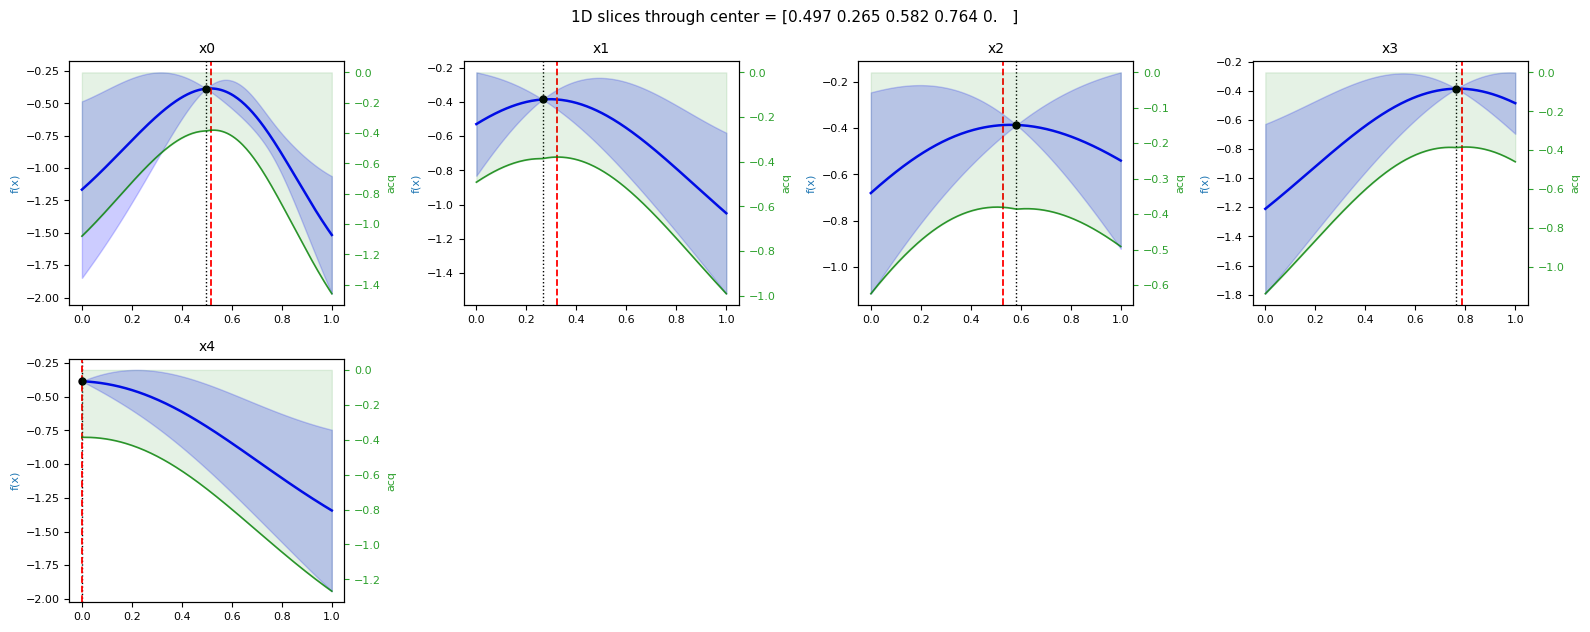

In [10]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refits once per observation, holding it out and predicting it from the rest. At D=5 this is my main way to judge the surrogate, since I cannot inspect the fitted surface directly.

I read the error bars rather than the correlation. 19 of 23 points fall inside their own 95% interval, and the worst-predicted point is week 3 — the out-of-domain one, missed by 0.84 against a predicted std of 0.41. That is both the point I am least able to predict and the one I would least like to revisit, so it costs me little.

[fitting: leave-one-out calibration] 21 warnings held back:
    21 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


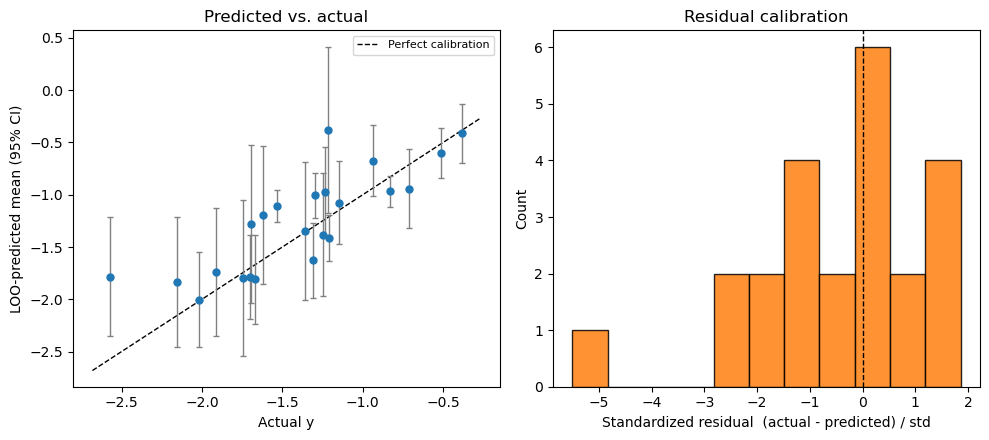

points inside their own 95% LOO interval: 19/23
worst-predicted: index 21 -> true -1.214796, predicted -0.377475 (std 0.405289)
  that point is from the collected #2


In [11]:
# random_state is pinned: gp_kwargs goes to fit_gp on every refit, so unseeded
# this cell was not reproducible run to run -- and the markdown states which
# point is worst-predicted, so that has to be stable.
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(
        X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20, "random_state": 0})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})")
src = "initial batch" if worst < n_initial else f"collected #{worst - n_initial + 1}"
print(f"  that point is from the {src}")


## Iteration diagnostics

Replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters and domain-wide uncertainty were at each past proposal. No persisted log involved.

**I have to lower `domain_grid_n` at D=5.** Its `domain_mean_std` field averages posterior std over a `domain_grid_n ** D` grid, so the default 40 means 40⁵ = 1.0e8 points, about 4 GB — it killed the kernel the first time I ran this notebook. The cell sizes the grid so `domain_grid_n ** D` stays near 200,000 whatever `D` is, which gives 11 here. That makes `domain_mean_std` a coarser estimate: still a fair basis for comparing one iteration in this run against another, but its absolute value is not comparable against a run that used a different grid.

Two caveats. The `kappa` is taken from `KAPPA` so it cannot drift from what the proposal used, but my history is **mixed** — earlier weeks were proposed under different settings, and `compute_iteration_diagnostics` applies one setting across the whole replay, so the `acq_value` column describes decisions that were never made that way. The GP-hyperparameter and `domain_mean_std` columns do not depend on the acquisition and are fine throughout.

`plot_bo_diagnostics` is skipped, since it hard-codes a 2D scatter panel. The trend plots below are dimension-agnostic and gated on having at least three completed iterations.

domain_grid_n = 11 -> 161,051 grid points (the default 40 would be 102,400,000)



Best y so far: -0.3861205609344592
completed iterations in the modelling set: 3

CAVEAT: my history is MIXED -- the 3 collected rows were not all
proposed under ucb/kappa=0.25, and compute_iteration_diagnostics applies one
setting across the whole replay. So acq_value is an artefact of that mismatch
rather than a property of the point. The GP-hyperparameter and domain_mean_std
columns don't depend on the acquisition and are fine throughout.


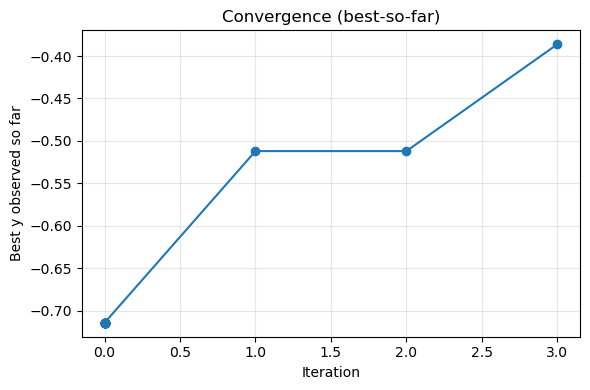

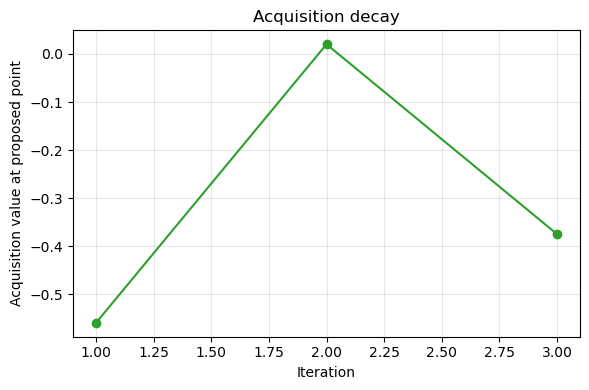

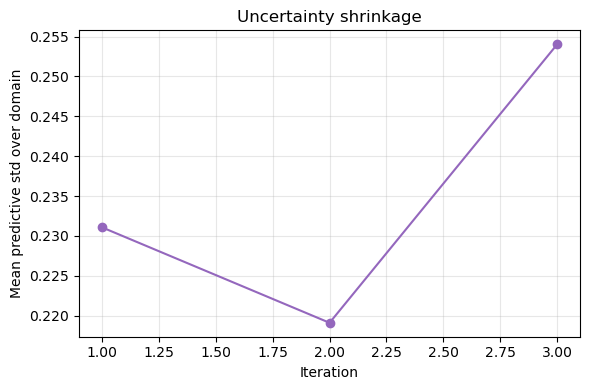

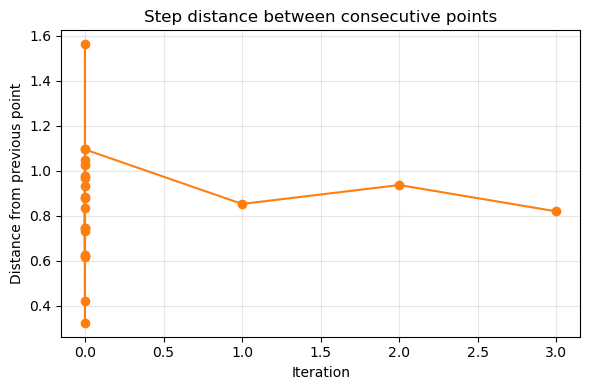

In [12]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default 40
# is 40**5 = 1.0e8 points (~4 GB) at D=5 and WILL kill the kernel -- it killed
# mine. Size it so the grid stays near 200k points whatever D is.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")

# The count comes from the MODELLING set rather than len(new_y), so it stays
# correct if I ever exclude rows from the fit.
n_replayed = len(y) - n_initial

with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True,
                                            domain_grid_n=DOMAIN_GRID_N)

print("\nBest y so far:", np.nanmax(history["y"]))
print("completed iterations in the modelling set:", n_replayed)
print(f"\nCAVEAT: my history is MIXED -- the {n_replayed} collected rows were not all")
print(f"proposed under ucb/kappa={KAPPA}, and compute_iteration_diagnostics applies one")
print("setting across the whole replay. So acq_value is an artefact of that mismatch")
print("rather than a property of the point. The GP-hyperparameter and domain_mean_std")
print("columns don't depend on the acquisition and are fine throughout.")

if n_replayed >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before the")
    print("trend plots say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [13]:
print("y:", np.round(history["y"], 5))
print("\niteration:", history["iteration"])
print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
print("\npred_mean at proposal time:", history["pred_mean"])
print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.71426 -1.20996 -1.6722  -1.53606 -0.82924 -1.24705 -1.23379 -1.69434
 -2.57117 -1.30912 -1.14478 -1.91268 -1.62284 -1.35668 -2.01843 -1.70256
 -1.29425 -0.93576 -2.15577 -1.74688 -0.51198 -1.2148  -0.38612]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3.]

acq_value (NaN = initial batch; see the caveat above): [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan -0.55889919  0.02016547 -0.37442478]

pred_mean at proposal time: [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan -0.59631764 -0.08701014 -0.41047556]

domain_mean_std: [       nan        nan        nan     

In [14]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.518201-0.321942-0.527558-0.786655-0.000000

full precision (use for next week's new_X):
0.5182010345352852-0.3219421805898162-0.5275575295367275-0.7866551873814568-0.0


In [15]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(6, new_X, x_next)


wrote weekly_data/function_6/inputs.csv: 4 row(s) (3 resulted + 1 proposal)
  proposal row: 0.518201-0.321942-0.527558-0.786655-0.000000


'weekly_data/function_6/inputs.csv'